# h5adify LLM benchmark — publication-ready plots

This notebook loads the results ZIP (predictions per model × DOI), derives reproducible summary metrics, and exports publication-ready figures:

- Accuracy / mapping quality per study
- Per-field heatmaps
- Model–model correlation heatmap
- Runtime per study
- Coverage of standardized fields
- UpSet-style intersections across models
- Clustered heatmap with dendrogram (marsilea-style layout without the library)
- Sankey-like bipartite mapping (selected raw column → standardized field) per model


In [9]:
import os, glob, json, re, zipfile, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Optional (for dendrogram)
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# ZIP_PATH = "/home/aalentorn/Téléchargements/experiments_part1.zip"   # <-- change if needed
# EXTRACT_DIR = "experiments_part1_extracted_viz"
OUTDIR = "../figures/part1"
# os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTDIR, exist_ok=True)

# with zipfile.ZipFile(ZIP_PATH, "r") as z:
#     z.extractall(EXTRACT_DIR)

# root = os.path.join(EXTRACT_DIR, "part1_4")
root = "../experiments/results/part1_4"
print("Root:", root)
print("Subdirs:", os.listdir(root))

Root: ../experiments/results/part1_4
Subdirs: ['gemma3_latest', 'llama3_latest', 'qwen3_8b', 'benchmark_run.log', 'mistral-nemo_12b']


In [3]:
# Model directories inside the zip
models_dirs = {
    "gemma3:latest": "gemma3_latest",
    "llama3:latest": "llama3_latest",
    "mistral-nemo:12b": "mistral-nemo_12b",
    "qwen3:8b": "qwen3_8b",
}

# DOI pretty names (fallback). Optional: add Crossref fetching below.
doi_pretty = {
    "10.1038_s41586-018-0654-5": "Tasic et al., 2018",
    "10.1038_s41586-020-2157-4": "Han et al., 2020",
    "10.1038_s41586-020-2496-1": "Tabula Muris Consortium, 2020",
    "10.1038_s41586-020-2922-4": "Travaglini et al., 2020",
}

fields = ["batch","donor","disease","sex","species","technology"]

# Parse all pred.json into a single dataframe
records = []
for model_name, d in models_dirs.items():
    pred_files = glob.glob(os.path.join(root, d, "10.*/**/pred.json"), recursive=True)
    for pf in pred_files:
        j = json.load(open(pf))
        doi = j.get("doi")
        doi_id = doi.replace("/", "_") if doi else None
        rep = j.get("report", {}) or {}
        cols = rep.get("columns_selection", {}) or {}
        glob_inf = rep.get("global_inference", {}) or {}
        thumb = rep.get("thumbnail", {}) or {}

        row = {
            "model": model_name,
            "model_dir": d,
            "doi": doi,
            "doi_id": doi_id,
            "paper": doi_pretty.get(doi_id, doi_id),
            "dataset_id": j.get("dataset_id"),
            "elapsed_sec": j.get("elapsed_sec"),
            "status": j.get("status"),
            "prompt_name": j.get("prompt_name"),
            "pred_path": pf,
        }

        for f in fields:
            row[f"sel_{f}"] = cols.get(f)
            gi = glob_inf.get(f, {}) if isinstance(glob_inf.get(f, {}), dict) else {}
            row[f"gi_value_{f}"] = gi.get("value")
            src = gi.get("source")
            if isinstance(src, list):
                row[f"gi_source_{f}"] = ";".join(map(str, src))
            else:
                row[f"gi_source_{f}"] = str(src) if src is not None else None

            th = thumb.get(f, {}) if isinstance(thumb.get(f, {}), dict) else {}
            row[f"thumb_nuniq_{f}"] = th.get("n_unique")
            ex = th.get("examples")
            row[f"thumb_examples_{f}"] = "|".join([str(x) for x in ex[:5]]) if isinstance(ex, list) else None

        records.append(row)

df = pd.DataFrame(records)
df.shape, df.head(2)


((16, 40),
            model      model_dir                        doi  \
 0  gemma3:latest  gemma3_latest  10.1038/s41586-020-2157-4   
 1  gemma3:latest  gemma3_latest  10.1038/s41586-020-2496-1   
 
                       doi_id                          paper  \
 0  10.1038_s41586-020-2157-4               Han et al., 2020   
 1  10.1038_s41586-020-2496-1  Tabula Muris Consortium, 2020   
 
                              dataset_id  elapsed_sec status  \
 0  2adb1f8a-a6b1-4909-8ee8-484814e2d4bf       42.019     ok   
 1  f16a8f4d-bc97-43c5-a2f6-bbda952e4c5c      102.791     ok   
 
                          prompt_name  \
 0  extraction_v2_default_no_examples   
 1  extraction_v2_default_no_examples   
 
                                            pred_path  ...  \
 0  ../experiments/results/part1_4/gemma3_latest/1...  ...   
 1  ../experiments/results/part1_4/gemma3_latest/1...  ...   
 
             sel_species gi_value_species  \
 0                   sex     Homo sapiens   
 1  sex

## Optional: fetch paper metadata (title / first author / year) from Crossref

If you want labels like *“FirstAuthor et al., Year”* automatically, enable this cell.
(Requires internet; safe fallback to `doi_pretty` if offline.)


In [ ]:
# Uncomment to enable:
# import requests
# def crossref_label(doi: str) -> str:
#     url = f"https://api.crossref.org/works/{doi}"
#     r = requests.get(url, timeout=30)
#     r.raise_for_status()
#     msg = r.json()["message"]
#     year = None
#     if "published-print" in msg and msg["published-print"].get("date-parts"):
#         year = msg["published-print"]["date-parts"][0][0]
#     elif "published-online" in msg and msg["published-online"].get("date-parts"):
#         year = msg["published-online"]["date-parts"][0][0]
#     authors = msg.get("author", [])
#     first = authors[0]["family"] if authors else "Unknown"
#     return f"{first} et al., {year}" if year else f"{first} et al."
#
# # Apply
# df["paper"] = df["doi"].apply(lambda d: crossref_label(d) if isinstance(d,str) else d)


## Heuristic scoring

Because the ZIP does not include a full gold standard, we compute a *mapping quality score* from `thumbnail.examples`:
- **1.0** if observed values match expected patterns (e.g., sex looks like `PATO:*`, technology mentions 10x/Visium/seq, etc.)
- **0.5** for partial matches
- **0.0** otherwise

You can replace this with your gold JSON if/when you include it.


In [4]:
patterns = {
    "sex": [r"^PATO:\d+$", r"^(male|female|both sexes|unknown)$"],
    "species": [r"^NCBITaxon:\d+$", r"(Mus musculus|Homo sapiens|mouse|human)"],
    "technology": [r"(10x|chromium|smart-?seq|drop-?seq|visium|seq|FACS|droplet|EFO:)"],
    "disease": [r"^MONDO:\d+$", r"(glioblastoma|cancer|tumou?r|normal|disease)"],
    "batch": [r"(batch|lane|run|\b\d+\b)"],
    "donor": [r"(donor|patient|subject|mouse|human|C57BL|ID|\b\d{2}-[MF]-\d+\b)"],
}

def score_field(field, examples_str):
    if examples_str is None or str(examples_str).strip() == "":
        return 0.0
    ex = str(examples_str).split("|")
    pats = patterns.get(field, [])
    if not pats:
        return 0.0
    def match_any(s):
        for p in pats:
            if re.search(p, s, flags=re.IGNORECASE):
                return True
        return False
    frac = sum(match_any(e) for e in ex) / max(1, len(ex))
    if frac >= 0.8:
        return 1.0
    if frac >= 0.3:
        return 0.5
    return 0.0

for f in fields:
    df[f"match_{f}"] = df[f"thumb_examples_{f}"].apply(lambda s: score_field(f, s))

df["match_mean"] = df[[f"match_{f}" for f in fields]].mean(axis=1)
df["match_core"] = df[[f"match_{f}" for f in ["sex","species","technology"]]].mean(axis=1)

df[["model","paper","match_mean","elapsed_sec"]].head()


,model,paper,match_mean,elapsed_sec
0,gemma3:latest,"Han et al., 2020",0.666667,42.019
1,gemma3:latest,"Tabula Muris Consortium, 2020",0.833333,102.791
2,gemma3:latest,"Tasic et al., 2018",0.500000,38.803
3,gemma3:latest,"Travaglini et al., 2020",0.500000,23.465
4,llama3:latest,"Han et al., 2020",0.666667,60.088


## Figures

In [5]:
models = list(models_dirs.keys())
papers = [doi_pretty[k] for k in doi_pretty.keys() if k in set(df["doi_id"].unique())]
print("Models:", models)
print("Papers:", papers)

Models: ['gemma3:latest', 'llama3:latest', 'mistral-nemo:12b', 'qwen3:8b']
Papers: ['Tasic et al., 2018', 'Han et al., 2020', 'Tabula Muris Consortium, 2020', 'Travaglini et al., 2020']


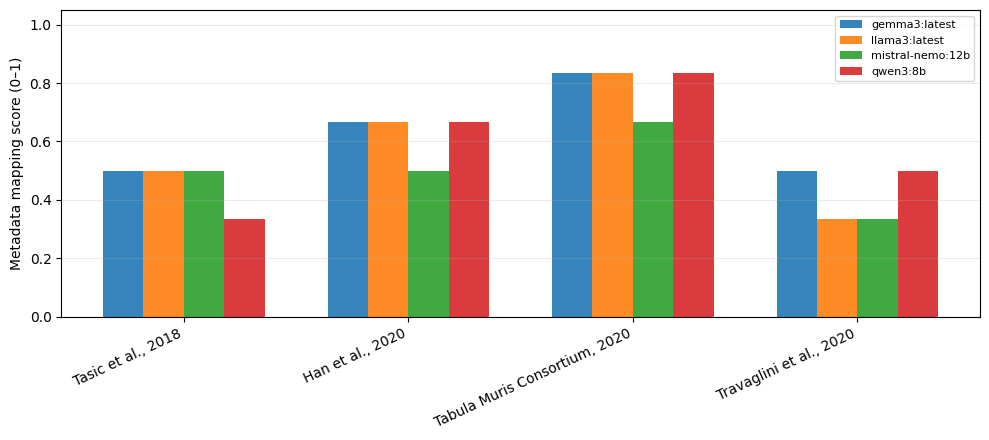

In [12]:
# FIG 1 — Accuracy per study (match_mean)
plt.figure(figsize=(10,4.5))
x = np.arange(len(papers))
width = 0.18
for i, m in enumerate(models):
    sub = df[df["model"]==m].set_index("paper").reindex(papers)
    vals = sub["match_mean"].values
    plt.bar(x + (i-(len(models)-1)/2)*width, vals, width=width, alpha=0.9, label=m)
plt.xticks(x, papers, rotation=25, ha="right")
plt.ylim(0,1.05)
plt.ylabel("Metadata mapping score (0–1)")
# plt.title("Metadata mapping quality per study (heuristic from observed values)")
plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=True, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Fig1_accuracy_per_study.png"), dpi=400)
plt.savefig(os.path.join(OUTDIR, "Fig1_accuracy_per_study.pdf"))
plt.show()


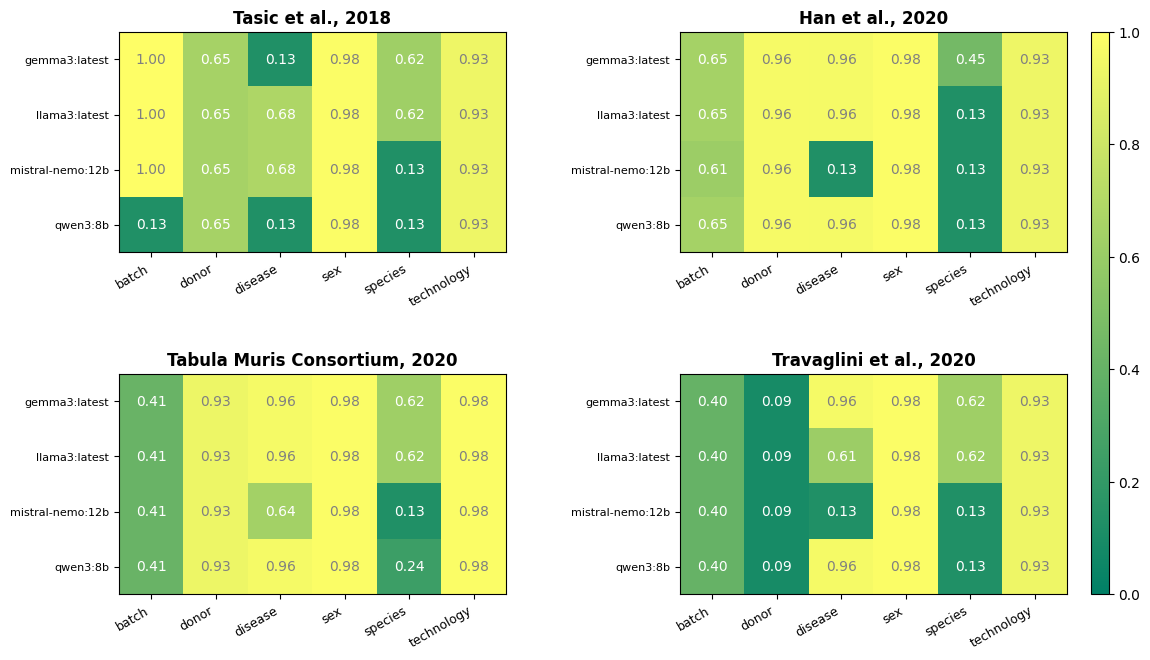

In [31]:
# FIG 2 (quantitative, improved layout) — Continuous mapping confidence per study (models × fields)
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# Requires: df has thumb_nuniq_{field} and thumb_examples_{field}
for f in fields:
    assert f"thumb_nuniq_{f}" in df.columns, f"Missing thumb_nuniq_{f} (ensure you parsed thumbnails)."
    assert f"thumb_examples_{f}" in df.columns, f"Missing thumb_examples_{f}"

patterns = {
    "sex": [r"^PATO:\d+$", r"^(male|female|both sexes|unknown)$"],
    "species": [r"^NCBITaxon:\d+$", r"(Mus musculus|Homo sapiens|mouse|human)"],
    "technology": [r"(10x|chromium|smart-?seq|drop-?seq|visium|seq|FACS|droplet|EFO:)"],
    "disease": [r"^MONDO:\d+$", r"(glioblastoma|cancer|tumou?r|normal|disease)"],
    "batch": [r"(batch|lane|run|\b\d+\b)"],
    "donor": [r"(donor|patient|subject|mouse|human|C57BL|ID|\b\d{2}-[MF]-\d+\b)"],
}

def example_match_fraction(field, examples_str):
    if examples_str is None or str(examples_str).strip() == "":
        return 0.0
    ex = str(examples_str).split("|")
    pats = patterns.get(field, [])
    if not pats:
        return 0.0
    def ok(s):
        return any(re.search(p, s, flags=re.IGNORECASE) for p in pats)
    return float(np.mean([ok(e) for e in ex]))

def continuous_field_score(row, field):
    nuniq = row.get(f"thumb_nuniq_{field}", np.nan)
    mf = example_match_fraction(field, row.get(f"thumb_examples_{field}", ""))

    if not np.isfinite(nuniq):
        nscore = 0.2
    else:
        nuniq = float(nuniq)
        if field == "sex":
            nscore = np.exp(-((nuniq - 2.5) / 3.0)**2)
        elif field == "species":
            nscore = np.exp(-((nuniq - 1.5) / 2.5)**2)
        elif field == "technology":
            nscore = np.exp(-((nuniq - 3.0) / 6.0)**2)
        elif field in ["batch", "donor"]:
            nscore = 1.0 - np.exp(-nuniq / 20.0)
        elif field == "disease":
            nscore = np.exp(-((nuniq - 3.0) / 8.0)**2)
        else:
            nscore = 0.5

    score = 0.65 * nscore + 0.35 * mf
    return float(np.clip(score, 0, 1))

for f in fields:
    df[f"qscore_{f}"] = df.apply(lambda r: continuous_field_score(r, f), axis=1)

# --- plot faceted heatmaps with MORE SPACING ---
n_papers = len(papers)
ncols = 2
nrows = int(np.ceil(n_papers / ncols))

fig = plt.figure(figsize=(6.0*ncols, 3.8*nrows))
gs = fig.add_gridspec(nrows, ncols, wspace=0.45, hspace=0.55)  # <-- more spacing

ims = []
for idx, paper in enumerate(papers):
    r, c = divmod(idx, ncols)
    ax = fig.add_subplot(gs[r, c])

    sub = df[df["paper"] == paper].set_index("model").reindex(models)
    mat_p = np.vstack([sub[f"qscore_{f}"].values for f in fields]).T  # models x fields

    im = ax.imshow(mat_p, aspect="auto", vmin=0, vmax=1, cmap="summer")
    ims.append(im)

    ax.set_title(paper, fontsize=12, fontweight="bold")

    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels(models, fontsize=8)  # <-- slightly smaller

    ax.set_xticks(np.arange(len(fields)))
    ax.set_xticklabels(fields, rotation=30, ha="right", fontsize=9)

    for i in range(mat_p.shape[0]):
        for j in range(mat_p.shape[1]):
            val = mat_p[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=10, color="gray" if val > 0.8 else "white")

# shared colorbar
cax = fig.add_axes([0.93, 0.12, 0.015, 0.74])
cb = fig.colorbar(ims[0], cax=cax)
# cb.set_label("Quantitative mapping confidence (0–1)")

# fig.suptitle("Quantitative per-field mapping confidence by model and study", fontsize=14, fontweight="bold", y=1.02)

# extra left margin so y labels never overlap/clip
plt.subplots_adjust(left=0.12, right=0.91, bottom=0.12, top=0.86)

out_png = os.path.join(OUTDIR, "Fig2_field_heatmap_quantitative_v2.png")
out_pdf = os.path.join(OUTDIR, "Fig2_field_heatmap_quantitative_v2.pdf")
plt.savefig(out_png, dpi=400, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

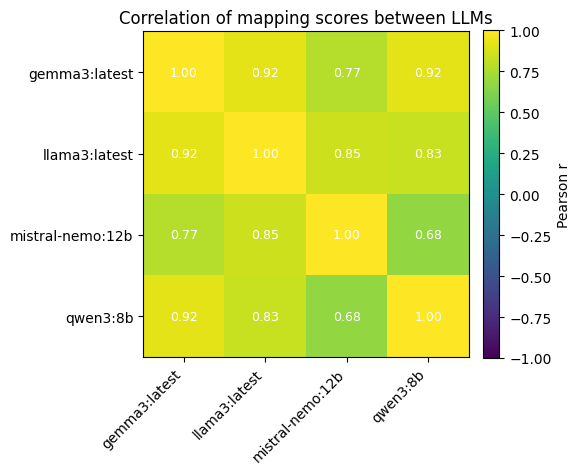

In [ ]:
# FIG 3 — Correlation between LLMs (Pearson r)
corr = np.corrcoef(mat)
plt.figure(figsize=(5.8,5.2))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.xticks(range(len(models)), models, rotation=45, ha="right")
plt.yticks(range(len(models)), models)
plt.title("Correlation of mapping scores between LLMs")
cb = plt.colorbar(im, fraction=0.046, pad=0.04)
cb.set_label("Pearson r")
for i in range(len(models)):
    for j in range(len(models)):
        plt.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=9,
                 color="gray" if abs(corr[i,j])>0.8 else "white")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Fig3_model_correlation.png"), dpi=300)
plt.savefig(os.path.join(OUTDIR, "Fig3_model_correlation.pdf"))
plt.show()


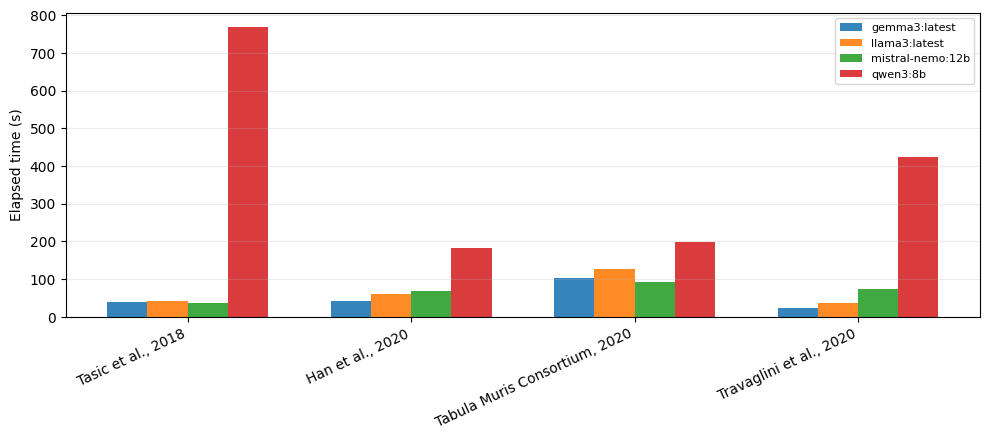

In [32]:
# FIG 4 — Runtime per study
plt.figure(figsize=(10,4.5))
x = np.arange(len(papers))
width = 0.18
for i, m in enumerate(models):
    sub = df[df["model"]==m].set_index("paper").reindex(papers)
    vals = sub["elapsed_sec"].values
    plt.bar(x + (i-(len(models)-1)/2)*width, vals, width=width, alpha=0.9, label=m)
plt.xticks(x, papers, rotation=25, ha="right")
plt.ylabel("Elapsed time (s)")
# plt.title("Runtime per study (per model)")
plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=True, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Fig4_runtime_per_study.png"), dpi=400)
plt.savefig(os.path.join(OUTDIR, "Fig4_runtime_per_study.pdf"))
plt.show()


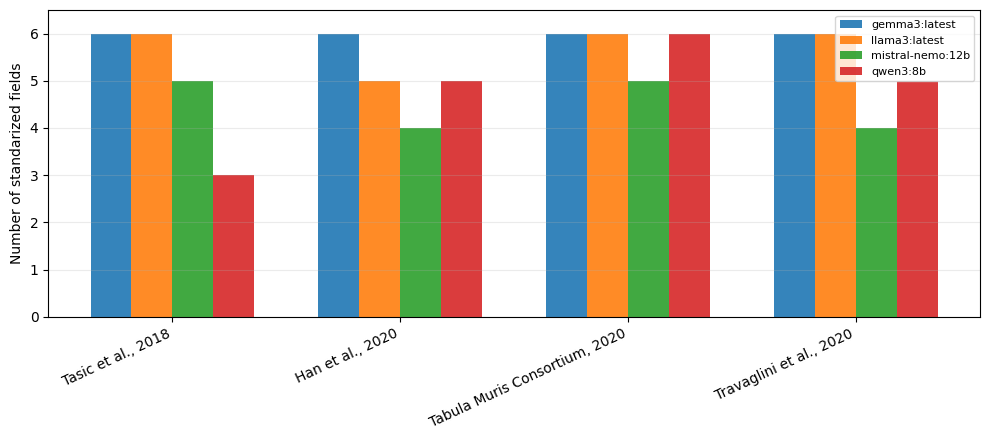

In [71]:
# FIG 5 — Coverage of standardized fields (sel_* not None)
df["n_fields_selected"] = df[[f"sel_{f}" for f in fields]].notna().sum(axis=1)

plt.figure(figsize=(10,4.5))
x = np.arange(len(papers))
width = 0.18
for i, m in enumerate(models):
    sub = df[df["model"]==m].set_index("paper").reindex(papers)
    vals = sub["n_fields_selected"].values
    plt.bar(x + (i-(len(models)-1)/2)*width, vals, width=width, alpha=0.9, label=m)
plt.xticks(x, papers, rotation=25, ha="right")
plt.ylabel("Number of standarized fields")
# plt.title("Coverage of harmonized fields per study")
plt.ylim(0, len(fields)+0.5)
plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=True, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Fig5_field_coverage.png"), dpi=400)
plt.savefig(os.path.join(OUTDIR, "Fig5_field_coverage.pdf"))
plt.show()


/tmp/ipykernel_448567/2459249342.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


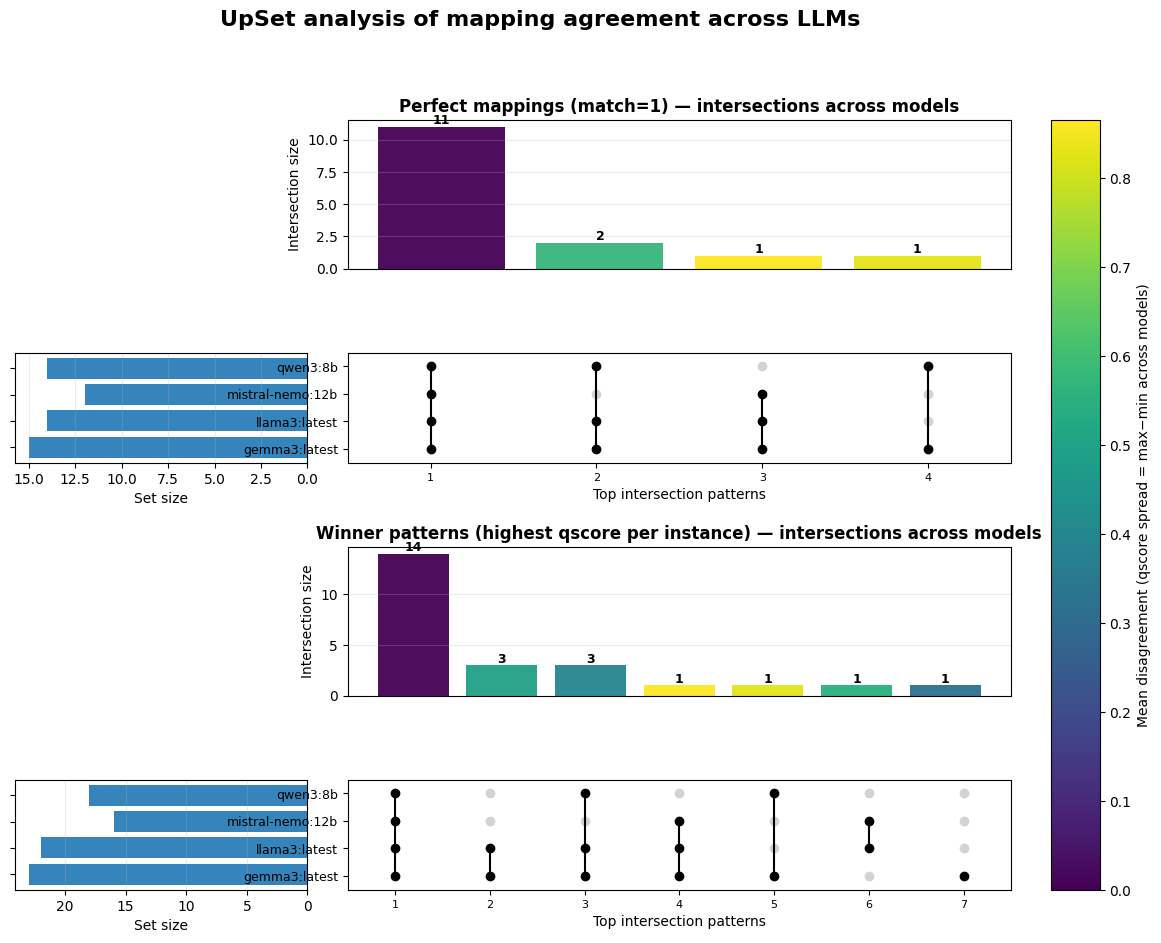

Wrote CSVs: h5adify_benchmark_figures/Fig6A_perfect_v4_intersections.csv h5adify_benchmark_figures/Fig6B_winner_v4_intersections.csv


In [27]:
# FIG 6 — UpSet plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import defaultdict

# ------------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------------
for f in fields:
    assert f"match_{f}" in df.columns, "Run match scoring first (match_* columns)."
    assert f"qscore_{f}" in df.columns, "Run quantitative scoring first (qscore_* columns)."

instances = [(p, f) for p in papers for f in fields]
inst_idx = {inst: i for i, inst in enumerate(instances)}
n_inst = len(instances)
M = len(models)

# ------------------------------------------------------------------
# Build matrices: match and qscore per model × instance
# ------------------------------------------------------------------
match_mat = np.zeros((M, n_inst), dtype=float)
q_mat = np.zeros((M, n_inst), dtype=float)

for mi, m in enumerate(models):
    subm = df[df["model"] == m].set_index("paper").reindex(papers)
    for p in papers:
        for f in fields:
            k = inst_idx[(p, f)]
            match_mat[mi, k] = float(subm.loc[p, f"match_{f}"])
            q_mat[mi, k] = float(subm.loc[p, f"qscore_{f}"])

# Disagreement per instance = spread across models
spread_inst = (np.nanmax(q_mat, axis=0) - np.nanmin(q_mat, axis=0))
spread_inst = np.nan_to_num(spread_inst, nan=0.0)

# GLOBAL vmax used everywhere (bars + colorbar)
global_vmax = float(np.max(spread_inst)) if len(spread_inst) else 1.0
global_norm = plt.Normalize(vmin=0.0, vmax=max(1e-12, global_vmax))
global_cmap = plt.get_cmap("viridis")

# ------------------------------------------------------------------
# Define 2 UpSet criteria
# ------------------------------------------------------------------
# A) Perfect mappings
bin_perfect = (match_mat >= 1.0 - 1e-9).astype(int)

# B) Winner patterns (best qscore per instance; ties allowed)
eps = 1e-6
max_q = np.nanmax(q_mat, axis=0, keepdims=True)
bin_winner = (q_mat >= (max_q - eps)).astype(int)

# ------------------------------------------------------------------
# UpSet computation
# ------------------------------------------------------------------
def compute_upset(binmat, spread_per_instance, top_k=16):
    set_sizes = binmat.sum(axis=1).astype(int)

    key_to_idxs = defaultdict(list)
    for k in range(binmat.shape[1]):
        key = tuple(binmat[:, k].astype(int).tolist())
        if any(key):
            key_to_idxs[key].append(k)

    items = []
    for key, idxs in key_to_idxs.items():
        ct = len(idxs)
        ms = float(np.mean(spread_per_instance[idxs])) if ct else 0.0
        items.append((key, ct, ms, idxs))

    # sort by size then disagreement
    items.sort(key=lambda x: (x[1], x[2]), reverse=True)
    items = items[:top_k]

    return {
        "keys": [it[0] for it in items],
        "counts": [it[1] for it in items],
        "mean_spread": [it[2] for it in items],
        "idxs": [it[3] for it in items],
        "set_sizes": set_sizes,
    }

def key_to_model_list(key):
    return [models[i] for i, b in enumerate(key) if b == 1]

# ------------------------------------------------------------------
# Plot helper (uses GLOBAL norm/cmap)
# ------------------------------------------------------------------
def plot_upset(ax_bar, ax_mat, ax_sets, upset, title, cmap, norm):
    keys = upset["keys"]
    counts = upset["counts"]
    mean_spread = upset["mean_spread"]
    set_sizes = upset["set_sizes"]

    x = np.arange(len(keys))

    # Colors with GLOBAL norm (consistent with colorbar)
    colors = [cmap(norm(ms)) for ms in mean_spread]

    ax_bar.bar(x, counts, color=colors, alpha=0.95)
    ax_bar.set_title(title, fontsize=12, fontweight="bold")
    ax_bar.set_ylabel("Intersection size")
    ax_bar.set_xticks([])
    ax_bar.grid(axis="y", alpha=0.25)

    for xi, ct in enumerate(counts):
        ax_bar.text(xi, ct, str(ct), ha="center", va="bottom", fontsize=9, fontweight="bold")

    # dot matrix
    ax_mat.set_xlim(-0.5, len(keys) - 0.5)
    ax_mat.set_ylim(-0.5, M - 0.5)
    ax_mat.set_yticks(range(M))
    ax_mat.set_yticklabels(models, fontsize=9)
    ax_mat.set_xticks(x)
    ax_mat.set_xticklabels([str(i + 1) for i in range(len(keys))], fontsize=8)
    ax_mat.set_xlabel("Top intersection patterns")
    ax_mat.grid(False)

    for xi, key in enumerate(keys):
        ys = [i for i, b in enumerate(key) if b == 1]
        for yi in range(M):
            ax_mat.plot(xi, yi, "o", markersize=6,
                        color="black" if key[yi] == 1 else "lightgray")
        if len(ys) >= 2:
            ax_mat.plot([xi, xi], [min(ys), max(ys)], "-", color="black", lw=1.5)

    # set sizes
    ax_sets.barh(np.arange(M), set_sizes, alpha=0.9)
    ax_sets.set_yticks(range(M))
    ax_sets.set_yticklabels([])
    ax_sets.set_xlabel("Set size")
    ax_sets.invert_xaxis()
    ax_sets.grid(axis="x", alpha=0.25)

# ------------------------------------------------------------------
# Compute UpSets
# ------------------------------------------------------------------
up_perfect = compute_upset(bin_perfect, spread_inst, top_k=16)
up_winner = compute_upset(bin_winner, spread_inst, top_k=16)

# ------------------------------------------------------------------
# Layout
# ------------------------------------------------------------------
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(
    4, 3,
    height_ratios=[0.46, 0.34, 0.46, 0.34],
    width_ratios=[0.30, 0.68, 0.05],
    hspace=0.65,
    wspace=0.12
)

ax_bar1  = fig.add_subplot(gs[0, 1])
ax_sets1 = fig.add_subplot(gs[1, 0])
ax_mat1  = fig.add_subplot(gs[1, 1])

ax_bar2  = fig.add_subplot(gs[2, 1])
ax_sets2 = fig.add_subplot(gs[3, 0])
ax_mat2  = fig.add_subplot(gs[3, 1])

plot_upset(ax_bar1, ax_mat1, ax_sets1, up_perfect,
           "Perfect mappings (match=1) — intersections across models",
           cmap=global_cmap, norm=global_norm)

plot_upset(ax_bar2, ax_mat2, ax_sets2, up_winner,
           "Winner patterns (highest qscore per instance) — intersections across models",
           cmap=global_cmap, norm=global_norm)

# shared colorbar (SAME norm)
cax = fig.add_subplot(gs[:, 2])
sm = plt.cm.ScalarMappable(cmap=global_cmap, norm=global_norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.set_label("Mean disagreement (qscore spread = max−min across models)", rotation=90)

fig.suptitle("UpSet analysis of mapping agreement across LLMs", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])

out_png = os.path.join(OUTDIR, "Fig6_upset_detailed_v4.png")
out_pdf = os.path.join(OUTDIR, "Fig6_upset_detailed_v4.pdf")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Optional CSV exports (unchanged)
# ------------------------------------------------------------------
def export_intersections(upset, prefix):
    rows = []
    for i, (key, ct, ms, idxs) in enumerate(zip(upset["keys"], upset["counts"], upset["mean_spread"], upset["idxs"]), start=1):
        inst_list = [f"{instances[k][0]}|{instances[k][1]}" for k in idxs]
        rows.append({
            "pattern_id": i,
            "models_in_pattern": ";".join(key_to_model_list(key)),
            "intersection_size": ct,
            "mean_disagreement_spread": ms,
            "instances": ";".join(inst_list),
        })
    pd.DataFrame(rows).to_csv(os.path.join(OUTDIR, f"{prefix}_intersections.csv"), index=False)

export_intersections(up_perfect, "Fig6A_perfect_v4")
export_intersections(up_winner,  "Fig6B_winner_v4")
print("Wrote CSVs:",
      os.path.join(OUTDIR, "Fig6A_perfect_v4_intersections.csv"),
      os.path.join(OUTDIR, "Fig6B_winner_v4_intersections.csv"))

/tmp/ipykernel_448567/3732463463.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


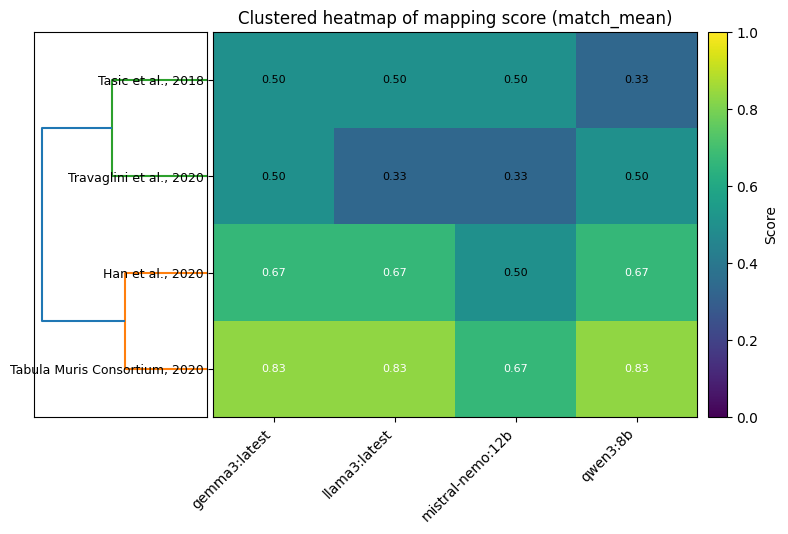

In [12]:
# FIG 7 — Clustered heatmap with dendrogram (marsilea-like layout without marsilea)
pmat = []
for p in papers:
    row=[]
    for m in models:
        row.append(df[(df["paper"]==p)&(df["model"]==m)]["match_mean"].values[0])
    pmat.append(row)
pmat = np.array(pmat)

Z = linkage(pdist(pmat, metric="euclidean"), method="average")

fig = plt.figure(figsize=(9,5))
gs = fig.add_gridspec(1, 2, width_ratios=[0.25,0.75], wspace=0.02)
ax_d = fig.add_subplot(gs[0])
ax_h = fig.add_subplot(gs[1])

dend = dendrogram(Z, labels=papers, orientation='left', ax=ax_d)
ax_d.tick_params(axis='x', bottom=False, labelbottom=False)

order = dend['ivl']
order_idx = [papers.index(p) for p in order]
hm = pmat[order_idx,:]

im = ax_h.imshow(hm, aspect='auto', vmin=0, vmax=1)
ax_h.set_yticks(range(len(order)))
ax_h.set_yticklabels(order, fontsize=9)
ax_h.set_xticks(range(len(models)))
ax_h.set_xticklabels(models, rotation=45, ha='right')
ax_h.set_title("Clustered heatmap of mapping score (match_mean)")
cb = plt.colorbar(im, ax=ax_h, fraction=0.046, pad=0.02)
cb.set_label("Score")

for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax_h.text(j, i, f"{hm[i,j]:.2f}", ha="center", va="center",
                  fontsize=8, color="white" if hm[i,j]>0.6 else "black")

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Fig7_clustered_heatmap.png"), dpi=300)
plt.savefig(os.path.join(OUTDIR, "Fig7_clustered_heatmap.pdf"))
plt.show()


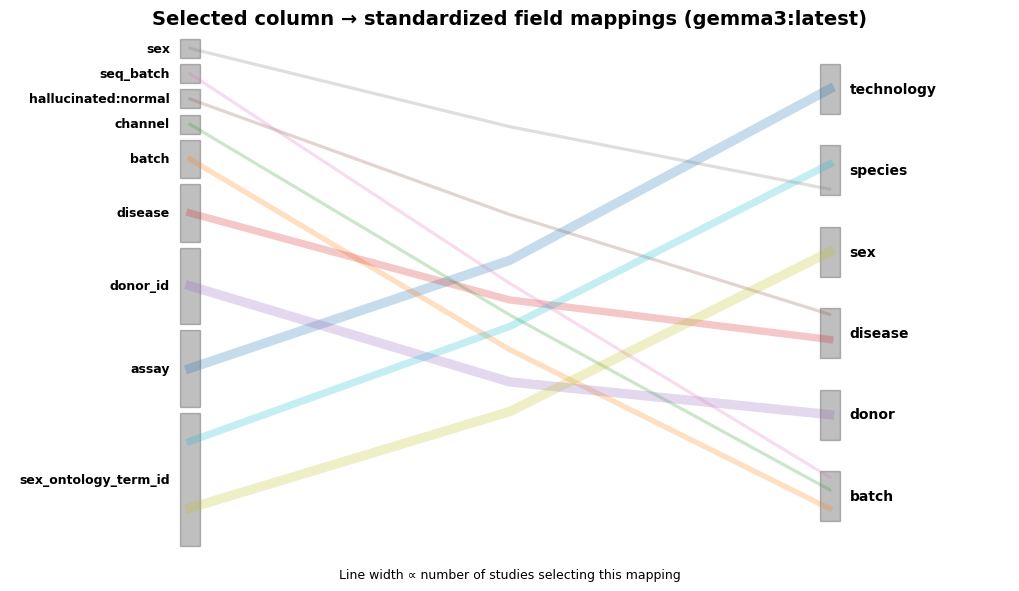

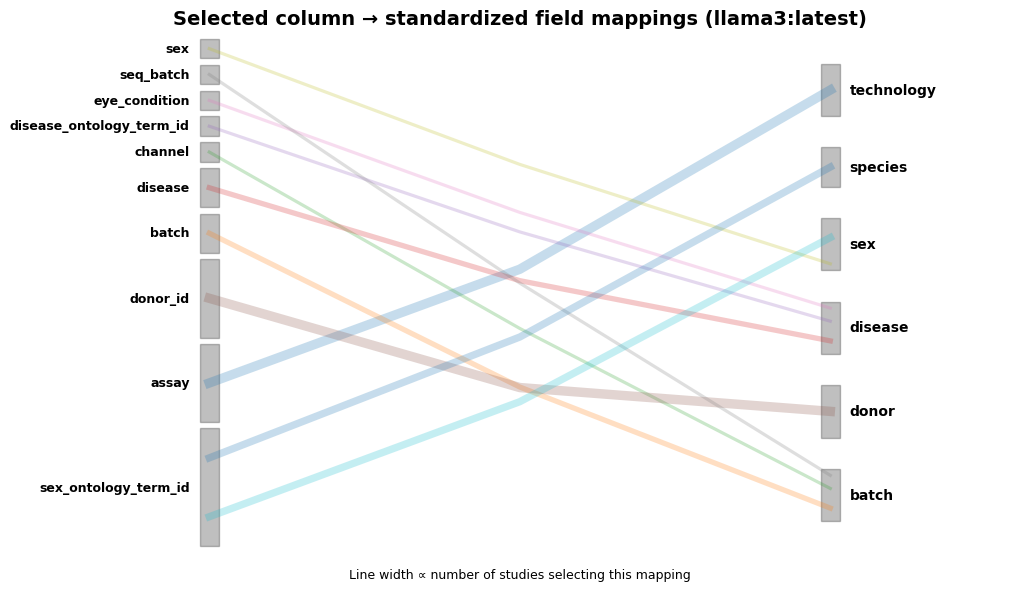

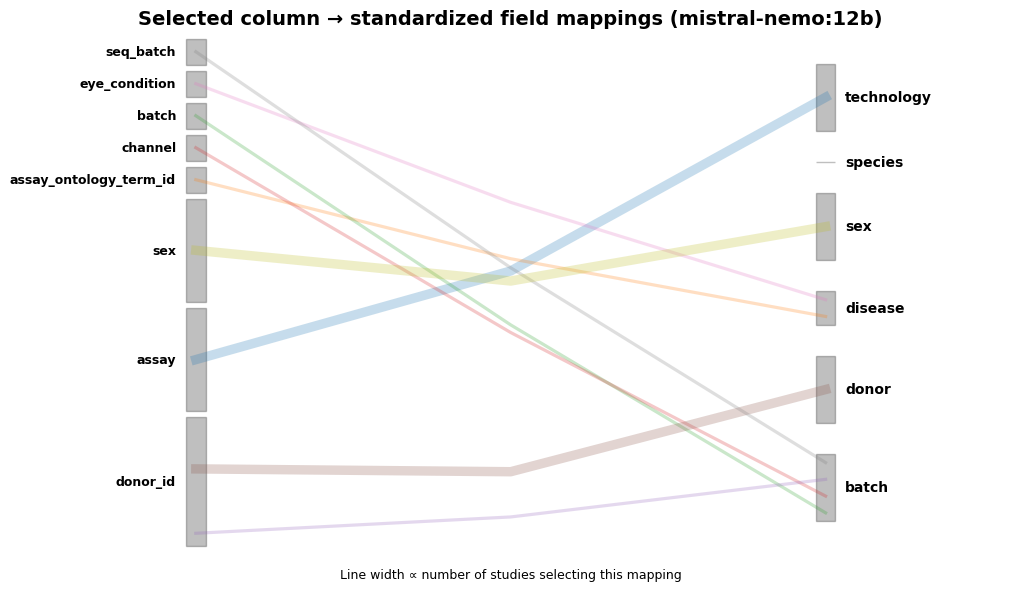

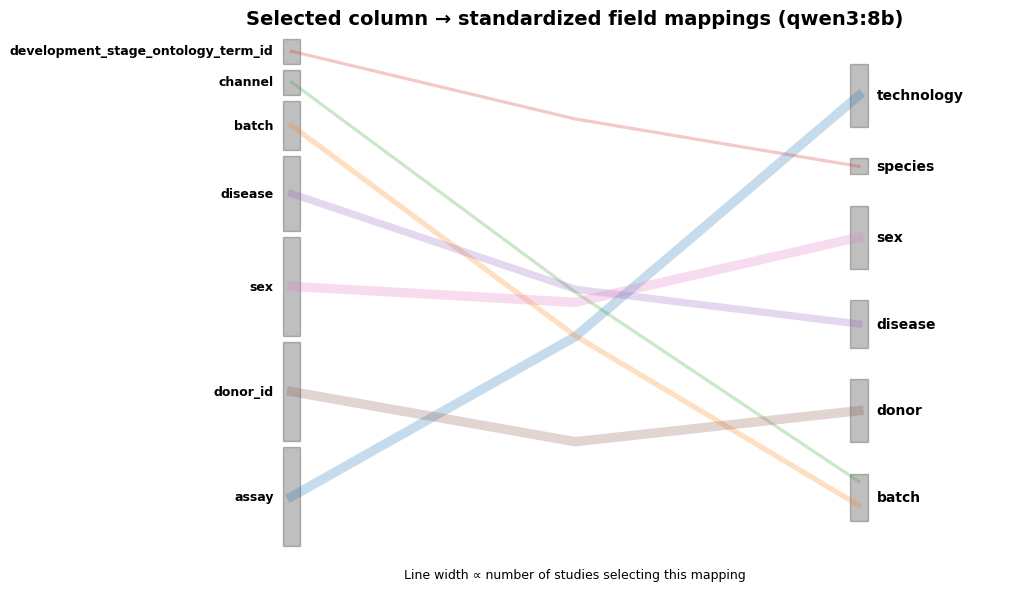

In [ ]:
# FIG 8 (fixed) — Robust Sankey-like bipartite mapping per model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os

def plot_bipartite_mapping_v2(model_name, outbase, top_k=12, min_count=1):
    """
    Robust alluvial-style plot:
      - Aggregates selected raw columns -> standardized fields across all studies.
      - Keeps only top_k most frequent raw columns; others grouped into 'Other'.
      - Avoids NaN/inf positions (safe normalization).
      - Produces readable layout even when mappings are sparse.
    """
    sub = df[df["model"] == model_name].copy()

    # build links
    links = []
    for _, r in sub.iterrows():
        for f in fields:
            src = r.get(f"sel_{f}")
            if src is None or (isinstance(src, float) and np.isnan(src)):
                continue
            links.append((str(src), str(f)))

    if len(links) == 0:
        print(f"[WARN] No links for {model_name}, skipping.")
        return

    link_df = pd.DataFrame(links, columns=["src", "dst"])
    counts = link_df.value_counts().reset_index(name="count")
    counts = counts[counts["count"] >= min_count].copy()

    # keep top_k src overall, group the rest
    src_totals = counts.groupby("src")["count"].sum().sort_values(ascending=False)
    keep_src = set(src_totals.head(top_k).index.tolist())
    counts["src2"] = counts["src"].where(counts["src"].isin(keep_src), other="Other")
    counts = counts.groupby(["src2", "dst"], as_index=False)["count"].sum()
    counts = counts.rename(columns={"src2": "src"})

    # nodes
    left_nodes = counts.groupby("src")["count"].sum().sort_values(ascending=False).index.tolist()
    right_nodes = list(fields)

    left_tot = counts.groupby("src")["count"].sum().reindex(left_nodes).fillna(0).values.astype(float)
    right_tot = counts.groupby("dst")["count"].sum().reindex(right_nodes).fillna(0).values.astype(float)

    totalL = left_tot.sum()
    totalR = right_tot.sum()

    if totalL <= 0 or totalR <= 0:
        print(f"[WARN] Degenerate totals for {model_name}, skipping.")
        return

    # allocate node spans in [0,1] with padding gaps
    def node_layout(tots, gap=0.012):
        tots = np.asarray(tots, float)
        tots = np.maximum(tots, 0)
        total = tots.sum()
        n = len(tots)
        usable = 1.0 - gap*(n+1)
        heights = (tots/total) * usable
        y0 = gap
        centers = []
        spans = []
        for h in heights:
            centers.append(y0 + h/2)
            spans.append((y0, y0+h))
            y0 = y0 + h + gap
        return np.array(centers), np.array(spans), heights

    yLc, yLspan, hL = node_layout(left_tot, gap=0.012)
    yRc, yRspan, hR = node_layout(right_tot, gap=0.06)

    # running offsets within each node (in "height units")
    left_offset = {n: 0.0 for n in left_nodes}
    right_offset = {n: 0.0 for n in right_nodes}

    left_total_map = dict(zip(left_nodes, left_tot))
    right_total_map = dict(zip(right_nodes, right_tot))

    # figure
    fig, ax = plt.subplots(figsize=(10.5, 6.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(f"Selected column → standardized field mappings ({model_name})",
                 fontsize=14, fontweight="bold")

    xL, xR = 0.18, 0.82

    # draw node bars + labels
    for i, n in enumerate(left_nodes):
        y0, y1 = yLspan[i]
        ax.add_patch(Rectangle((xL-0.01, y0), 0.02, y1-y0, color="black", alpha=0.25))
        ax.text(xL-0.02, yLc[i], n, ha="right", va="center", fontsize=9, fontweight="bold")

    for i, n in enumerate(right_nodes):
        y0, y1 = yRspan[i]
        ax.add_patch(Rectangle((xR-0.01, y0), 0.02, y1-y0, color="black", alpha=0.25))
        ax.text(xR+0.02, yRc[i], n, ha="left", va="center", fontsize=10, fontweight="bold")

    # links
    maxc = max(1, counts["count"].max())
    for _, row in counts.iterrows():
        src, dst, c = row["src"], row["dst"], float(row["count"])
        if src not in left_nodes or dst not in right_nodes:
            continue

        iL = left_nodes.index(src)
        iR = right_nodes.index(dst)

        # link height proportional to c within node span
        srcH = (yLspan[iL][1] - yLspan[iL][0])
        dstH = (yRspan[iR][1] - yRspan[iR][0])

        # fractions within each node
        fracL = c / left_total_map[src] if left_total_map[src] > 0 else 0
        fracR = c / right_total_map[dst] if right_total_map[dst] > 0 else 0

        linkH_L = srcH * fracL
        linkH_R = dstH * fracR

        # y positions within nodes
        y0 = yLspan[iL][0] + left_offset[src]
        y1 = yRspan[iR][0] + right_offset[dst]
        left_offset[src] += linkH_L
        right_offset[dst] += linkH_R

        # draw a simple curved-ish polyline (no bubbles, no external libs)
        lw = 0.8 + 6.0*(c/maxc)
        ax.plot([xL, (xL+xR)/2, xR], [y0 + linkH_L/2, (y0+y1)/2, y1 + linkH_R/2],
                alpha=0.25, lw=lw)

    ax.text(0.5, -0.03, "Line width ∝ number of studies selecting this mapping",
            ha="center", va="top", fontsize=9)

    plt.tight_layout()
    plt.savefig(outbase + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", bbox_inches="tight")
    plt.show()

# regenerate Fig8 for all models
for m in models:
    base = os.path.join(OUTDIR, f"Fig8_sankey_like_FIXED_{m.replace(':','_').replace('-','_')}")
    plot_bipartite_mapping_v2(m, base, top_k=12)

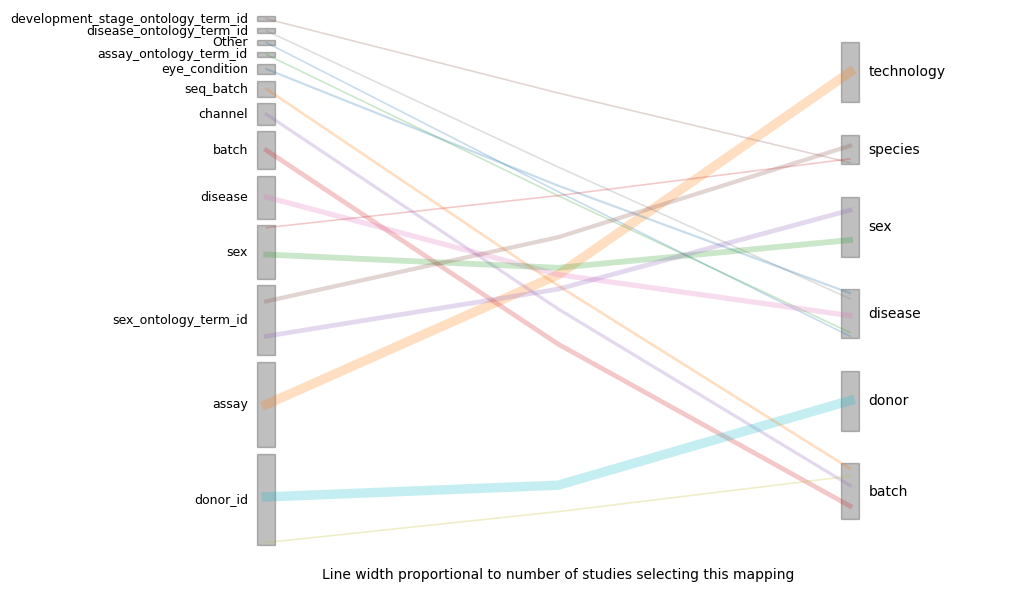

In [70]:
# FIG 8 (fixed) — Robust Sankey-like bipartite mapping per model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os

def plot_bipartite_mapping_v2(outbase, top_k=12, min_count=1):
    """
    Robust alluvial-style plot:
      - Aggregates selected raw columns -> standardized fields across all studies.
      - Keeps only top_k most frequent raw columns; others grouped into 'Other'.
      - Avoids NaN/inf positions (safe normalization).
      - Produces readable layout even when mappings are sparse.
    """
    sub = df.copy()

    # build links
    links = []
    for _, r in sub.iterrows():
        for f in fields:
            src = r.get(f"sel_{f}")
            if src is None or (isinstance(src, float) and np.isnan(src)):
                continue
            links.append((str(src), str(f)))

    if len(links) == 0:
        print(f"[WARN] No links, skipping.")
        return

    link_df = pd.DataFrame(links, columns=["src", "dst"])
    counts = link_df.value_counts().reset_index(name="count")
    counts = counts[counts["count"] >= min_count].copy()

    # keep top_k src overall, group the rest
    src_totals = counts.groupby("src")["count"].sum().sort_values(ascending=False)
    keep_src = set(src_totals.head(top_k).index.tolist())
    counts["src2"] = counts["src"].where(counts["src"].isin(keep_src), other="Other")
    counts = counts.groupby(["src2", "dst"], as_index=False)["count"].sum()
    counts = counts.rename(columns={"src2": "src"})

    # nodes
    left_nodes = counts.groupby("src")["count"].sum().sort_values(ascending=False).index.tolist()
    right_nodes = list(fields)

    left_tot = counts.groupby("src")["count"].sum().reindex(left_nodes).fillna(0).values.astype(float)
    right_tot = counts.groupby("dst")["count"].sum().reindex(right_nodes).fillna(0).values.astype(float)

    totalL = left_tot.sum()
    totalR = right_tot.sum()

    if totalL <= 0 or totalR <= 0:
        print(f"[WARN] Degenerate totals, skipping.")
        return

    # allocate node spans in [0,1] with padding gaps
    def node_layout(tots, gap=0.012):
        tots = np.asarray(tots, float)
        tots = np.maximum(tots, 0)
        total = tots.sum()
        n = len(tots)
        usable = 1.0 - gap*(n+1)
        heights = (tots/total) * usable
        y0 = gap
        centers = []
        spans = []
        for h in heights:
            centers.append(y0 + h/2)
            spans.append((y0, y0+h))
            y0 = y0 + h + gap
        return np.array(centers), np.array(spans), heights

    yLc, yLspan, hL = node_layout(left_tot, gap=0.012)
    yRc, yRspan, hR = node_layout(right_tot, gap=0.06)

    # running offsets within each node (in "height units")
    left_offset = {n: 0.0 for n in left_nodes}
    right_offset = {n: 0.0 for n in right_nodes}

    left_total_map = dict(zip(left_nodes, left_tot))
    right_total_map = dict(zip(right_nodes, right_tot))

    # figure
    fig, ax = plt.subplots(figsize=(10.5, 6.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    # ax.set_title(f"Selected column → standardized field mappings", fontsize=14, fontweight="bold")

    xL, xR = 0.18, 0.82

    # draw node bars + labels
    for i, n in enumerate(left_nodes):
        y0, y1 = yLspan[i]
        ax.add_patch(Rectangle((xL-0.01, y0), 0.02, y1-y0, color="black", alpha=0.25))
        ax.text(xL-0.02, yLc[i], n, ha="right", va="center", fontsize=9) #, fontweight="bold")

    for i, n in enumerate(right_nodes):
        y0, y1 = yRspan[i]
        ax.add_patch(Rectangle((xR-0.01, y0), 0.02, y1-y0, color="black", alpha=0.25))
        ax.text(xR+0.02, yRc[i], n, ha="left", va="center", fontsize=10) #, fontweight="bold")

    # links
    maxc = max(1, counts["count"].max())
    for _, row in counts.iterrows():
        src, dst, c = row["src"], row["dst"], float(row["count"])
        if src not in left_nodes or dst not in right_nodes:
            continue

        iL = left_nodes.index(src)
        iR = right_nodes.index(dst)

        # link height proportional to c within node span
        srcH = (yLspan[iL][1] - yLspan[iL][0])
        dstH = (yRspan[iR][1] - yRspan[iR][0])

        # fractions within each node
        fracL = c / left_total_map[src] if left_total_map[src] > 0 else 0
        fracR = c / right_total_map[dst] if right_total_map[dst] > 0 else 0

        linkH_L = srcH * fracL
        linkH_R = dstH * fracR

        # y positions within nodes
        y0 = yLspan[iL][0] + left_offset[src]
        y1 = yRspan[iR][0] + right_offset[dst]
        left_offset[src] += linkH_L
        right_offset[dst] += linkH_R

        # draw a simple curved-ish polyline (no bubbles, no external libs)
        lw = 0.8 + 6.0*(c/maxc)
        ax.plot([xL, (xL+xR)/2, xR], [y0 + linkH_L/2, (y0+y1)/2, y1 + linkH_R/2],
                alpha=0.25, lw=lw)

    ax.text(0.5, -0.03, "Line width proportional to number of studies selecting this mapping",
            ha="center", va="top", fontsize=10)

    plt.tight_layout()
    plt.savefig(outbase + ".png", dpi=400, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", bbox_inches="tight")
    plt.show()

# regenerate Fig8 for all models
base = os.path.join(OUTDIR, f"Fig8_sankey_like_FIXED")
plot_bipartite_mapping_v2(base, top_k=12)

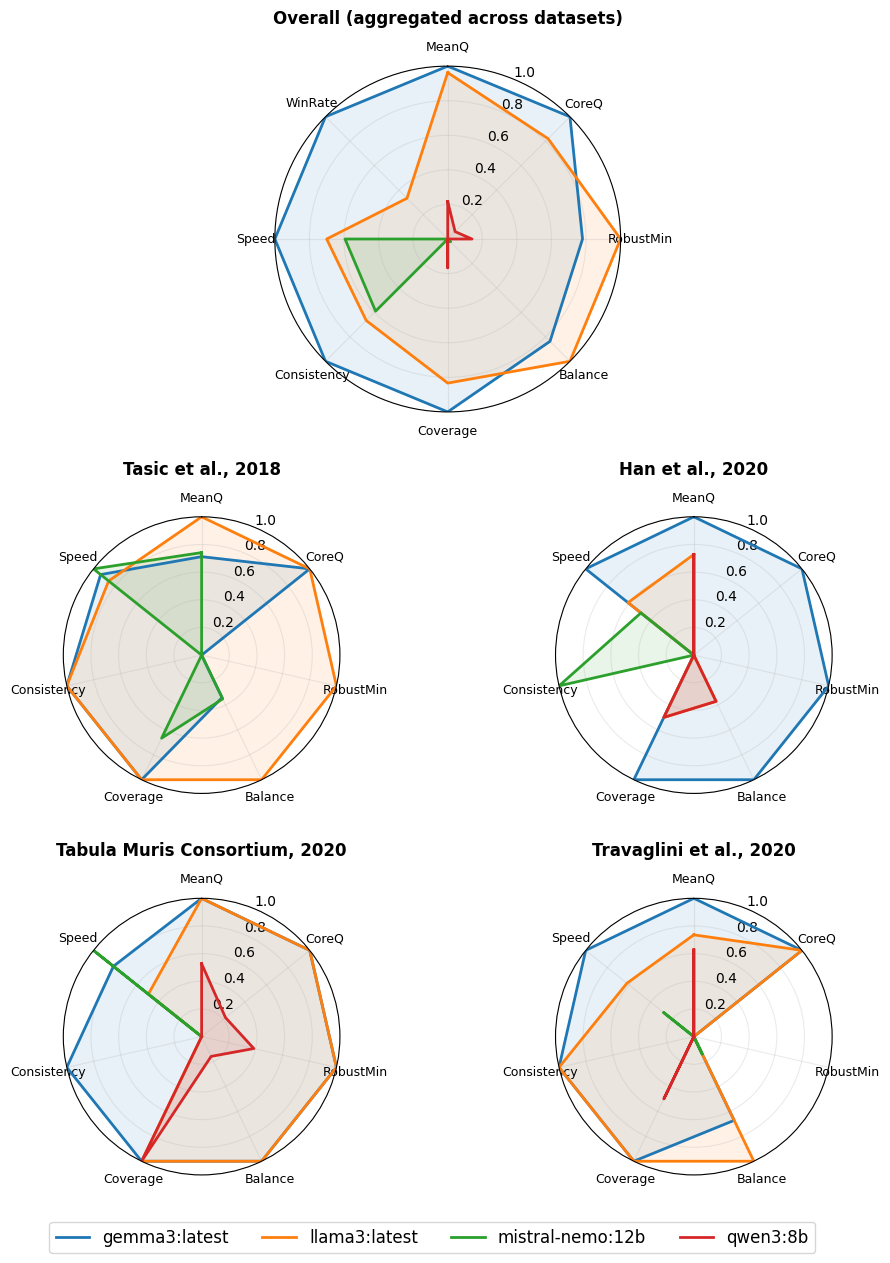

In [65]:
# FIG 9 — Radar using quantitative heatmap scores + runtime; includes OVERALL + per-dataset panels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re
from collections import Counter

# -----------------------------
# 0) Ensure qscore_* exists (derived from the same logic as Fig 2 quantitative heatmap)
# -----------------------------
patterns = {
    "sex": [r"^PATO:\d+$", r"^(male|female|both sexes|unknown)$"],
    "species": [r"^NCBITaxon:\d+$", r"(Mus musculus|Homo sapiens|mouse|human)"],
    "technology": [r"(10x|chromium|smart-?seq|drop-?seq|visium|seq|FACS|droplet|EFO:)"],
    "disease": [r"^MONDO:\d+$", r"(glioblastoma|cancer|tumou?r|normal|disease)"],
    "batch": [r"(batch|lane|run|\b\d+\b)"],
    "donor": [r"(donor|patient|subject|mouse|human|C57BL|ID|\b\d{2}-[MF]-\d+\b)"],
}

def example_match_fraction(field, examples_str):
    if examples_str is None or str(examples_str).strip() == "":
        return 0.0
    ex = str(examples_str).split("|")
    pats = patterns.get(field, [])
    if not pats:
        return 0.0
    def ok(s):
        return any(re.search(p, s, flags=re.IGNORECASE) for p in pats)
    return float(np.mean([ok(e) for e in ex]))

def continuous_field_score(row, field):
    nuniq = row.get(f"thumb_nuniq_{field}", np.nan)
    mf = example_match_fraction(field, row.get(f"thumb_examples_{field}", ""))

    if not np.isfinite(nuniq):
        nscore = 0.2
    else:
        nuniq = float(nuniq)
        if field == "sex":
            nscore = np.exp(-((nuniq - 2.5) / 3.0)**2)
        elif field == "species":
            nscore = np.exp(-((nuniq - 1.5) / 2.5)**2)
        elif field == "technology":
            nscore = np.exp(-((nuniq - 3.0) / 6.0)**2)
        elif field in ["batch", "donor"]:
            nscore = 1.0 - np.exp(-nuniq / 20.0)
        elif field == "disease":
            nscore = np.exp(-((nuniq - 3.0) / 8.0)**2)
        else:
            nscore = 0.5

    score = 0.65 * nscore + 0.35 * mf
    return float(np.clip(score, 0, 1))

# compute qscore if missing
need_q = any([f"qscore_{f}" not in df.columns for f in fields])
if need_q:
    for f in fields:
        df[f"qscore_{f}"] = df.apply(lambda r: continuous_field_score(r, f), axis=1)

# -----------------------------
# 1) Define richer radar features from qscore + runtime + selection behavior
# -----------------------------
core_fields = [f for f in ["sex", "species", "technology"] if f in fields]

# selection consistency per row (1 - normalized entropy)
def selection_consistency(row):
    sels = []
    for f in fields:
        v = row.get(f"sel_{f}", None)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        sels.append(str(v))
    if len(sels) == 0:
        return 0.0
    counts = Counter(sels)
    probs = np.array(list(counts.values()), dtype=float)
    probs /= probs.sum()
    H = -np.sum(probs * np.log(probs + 1e-12))
    Hmax = np.log(len(probs) + 1e-12)
    return float(1.0 - (H / (Hmax + 1e-12)))

if "consistency" not in df.columns:
    df["consistency"] = df.apply(selection_consistency, axis=1)

# coverage
if "n_fields_selected" not in df.columns:
    df["n_fields_selected"] = df[[f"sel_{f}" for f in fields]].notna().sum(axis=1)
df["coverage"] = df["n_fields_selected"] / max(1, len(fields))

# runtime -> speed
t = pd.to_numeric(df.get("elapsed_sec", np.nan), errors="coerce")
if np.isfinite(t).any():
    t_fill = t.fillna(t.max())
else:
    t_fill = pd.Series(np.ones(len(df)))
df["speed_raw"] = 1.0 / np.maximum(t_fill.values.astype(float), 1e-6)

# summary qscore features
df["q_mean"] = df[[f"qscore_{f}" for f in fields]].mean(axis=1)
df["q_core"] = df[[f"qscore_{f}" for f in core_fields]].mean(axis=1) if len(core_fields) else 0.0
df["q_min"]  = df[[f"qscore_{f}" for f in fields]].min(axis=1)
df["q_balance"] = 1.0 - df[[f"qscore_{f}" for f in fields]].std(axis=1).fillna(0.0)  # higher=more balanced

# -----------------------------
# 2) Radar helper
# -----------------------------
def radar(ax, categories, series_dict, title):
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.25)

    for label, vals in series_dict.items():
        vals = np.asarray(vals, dtype=float)
        vals = np.concatenate([vals, [vals[0]]])
        line = ax.plot(angles, vals, lw=2, label=label)[0]
        ax.fill(angles, vals, alpha=0.10, color=line.get_color())

    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)

def minmax_norm(v):
    v = np.asarray(v, dtype=float)
    v = np.nan_to_num(v, nan=np.nanmin(v) if np.isfinite(v).any() else 0.0)
    vmin, vmax = np.min(v), np.max(v)
    return (v - vmin) / (vmax - vmin + 1e-9)

# -----------------------------
# 3) OVERALL radar (consistency across datasets)
#    - Aggregate per model across papers (mean)
#    - Add WinRate: fraction of datasets where model is best on q_mean
# -----------------------------
feat_labels_overall = ["MeanQ", "CoreQ", "RobustMin", "Balance", "Coverage", "Consistency", "Speed", "WinRate"]

# compute per-model per-paper q_mean to rank winners
winners = []
for p in papers:
    sub = df[df["paper"] == p].set_index("model").reindex(models)
    q = pd.to_numeric(sub["q_mean"], errors="coerce").values.astype(float)
    if np.isfinite(q).any():
        winners.append(np.nanargmax(q))
win_counts = np.zeros(len(models), dtype=float)
for w in winners:
    win_counts[w] += 1
win_rate = win_counts / max(1, len(papers))

overall = []
for mi, m in enumerate(models):
    subm = df[df["model"] == m]
    # aggregate across datasets
    overall.append({
        "model": m,
        "MeanQ": float(np.nanmean(subm["q_mean"])),
        "CoreQ": float(np.nanmean(subm["q_core"])),
        "RobustMin": float(np.nanmean(subm["q_min"])),
        "Balance": float(np.nanmean(subm["q_balance"])),
        "Coverage": float(np.nanmean(subm["coverage"])),
        "Consistency": float(np.nanmean(subm["consistency"])),
        "Speed": float(np.nanmean(subm["speed_raw"])),
        "WinRate": float(win_rate[mi]),
    })
overall_df = pd.DataFrame(overall).set_index("model").reindex(models)

# normalize each feature across models (so “best overall” pops)
overall_norm = {}
for f in feat_labels_overall:
    overall_norm[f] = minmax_norm(overall_df[f].values)

series_overall = {m: [overall_norm[f][mi] for f in feat_labels_overall] for mi, m in enumerate(models)}

# -----------------------------
# 4) Per-dataset radars (use same axes but WITHOUT WinRate)
# -----------------------------
feat_labels_ds = ["MeanQ", "CoreQ", "RobustMin", "Balance", "Coverage", "Consistency", "Speed"]

def build_series_for_paper(paper):
    sub = df[df["paper"] == paper].set_index("model").reindex(models)
    raw = {
        "MeanQ": sub["q_mean"].values.astype(float),
        "CoreQ": sub["q_core"].values.astype(float),
        "RobustMin": sub["q_min"].values.astype(float),
        "Balance": sub["q_balance"].values.astype(float),
        "Coverage": sub["coverage"].values.astype(float),
        "Consistency": sub["consistency"].values.astype(float),
        "Speed": sub["speed_raw"].values.astype(float),
    }
    # normalize each feature within dataset to [0,1]
    norm = {k: minmax_norm(v) for k, v in raw.items()}
    return {m: [norm[f][mi] for f in feat_labels_ds] for mi, m in enumerate(models)}

# -----------------------------
# 5) Figure layout: top overall radar, bottom 2x2 per dataset
# -----------------------------
n_papers = len(papers)
ncols = 2
nrows = int(np.ceil(n_papers / ncols))

fig = plt.figure(figsize=(6.2*ncols, 4.8*nrows + 4.8))
gs = fig.add_gridspec(nrows + 1, ncols, height_ratios=[1] + [0.8]*nrows, hspace=0.35, wspace=0.05)

# Overall radar spans both columns
ax0 = fig.add_subplot(gs[0, :], polar=True)
radar(ax0, feat_labels_overall, series_overall, title="Overall (aggregated across datasets)")

last_ax = ax0

# Dataset radars
for idx, paper in enumerate(papers):
    r = 1 + (idx // ncols)
    c = idx % ncols
    ax = fig.add_subplot(gs[r, c], polar=True)
    last_ax = ax
    series = build_series_for_paper(paper)
    radar(ax, feat_labels_ds, series, title=paper)

# Legend (single)
handles, labels = last_ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.05), ncol=4, frameon=True, fontsize=12)

# fig.suptitle("Model comparison using quantitative mapping confidence + runtime", fontsize=15, fontweight="bold", y=0.99)

# plt.tight_layout(rect=[0, 0, 1, 0.7])

out_png = os.path.join(OUTDIR, "Fig9_spider_overall_and_per_dataset.png")
out_pdf = os.path.join(OUTDIR, "Fig9_spider_overall_and_per_dataset.pdf")
plt.savefig(out_png, dpi=400, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

In [ ]:
# Export an index CSV of generated figures
fig_files = sorted(glob.glob(os.path.join(OUTDIR, "*.png")))
pd.DataFrame({"figure_png": fig_files}).to_csv(os.path.join(OUTDIR, "FIGURES_INDEX.csv"), index=False)
print("Wrote:", os.path.join(OUTDIR, "FIGURES_INDEX.csv"))
print("Figures:", len(fig_files))
fig_files[:5]


In [23]:
# ============================================================
# Reproducibility / environment dump (run at the end of notebook)
# ============================================================
import os, sys, platform, subprocess, textwrap, json
from datetime import datetime

def _run(cmd):
    try:
        out = subprocess.check_output(cmd, stderr=subprocess.STDOUT, text=True)
        return out.strip()
    except Exception as e:
        return f"[FAILED] {cmd}\n{e}"

def _safe_import_version(modname):
    try:
        mod = __import__(modname)
        ver = getattr(mod, "__version__", None)
        return ver if ver is not None else "unknown"
    except Exception:
        return None

def dump_reproducibility(out_txt=None, extra_modules=None):
    """
    Prints (and optionally saves) key reproducibility info:
      - time, OS, Python
      - git commit (if in a git repo)
      - pip freeze + conda env (if available)
      - key library versions (scanpy/anndata/numpy/pandas/scipy/matplotlib/omicverse/etc)
      - CPU/GPU/CUDA info when possible
    """
    lines = []
    lines.append("="*80)
    lines.append("REPRODUCIBILITY REPORT")
    lines.append("="*80)
    lines.append(f"Timestamp (UTC): {datetime.utcnow().isoformat()}Z")
    lines.append(f"Working dir:      {os.getcwd()}")
    lines.append(f"Python:           {sys.version.replace(os.linesep,' ')}")
    lines.append(f"Executable:       {sys.executable}")
    lines.append(f"Platform:         {platform.platform()}")
    lines.append(f"Machine:          {platform.machine()} | Processor: {platform.processor()}")
    lines.append("")

    # ---- Key Python package versions
    key_mods = [
        "numpy", "pandas", "scipy", "matplotlib",
        "scanpy", "anndata",
        "sklearn",            # scikit-learn
        "statsmodels",        # if used
        "seaborn",            # if used
        "omicverse",
        "torch", "jax", "tensorflow",
        "cupy", "rapids",     # sometimes present
    ]
    if extra_modules:
        key_mods += list(extra_modules)

    lines.append("-"*80)
    lines.append("KEY PACKAGE VERSIONS")
    lines.append("-"*80)
    for m in key_mods:
        ver = _safe_import_version(m)
        if ver is not None:
            lines.append(f"{m:12s} {ver}")
    lines.append("")

    # ---- CUDA / GPU / Torch info (if available)
    lines.append("-"*80)
    lines.append("GPU / CUDA (best-effort)")
    lines.append("-"*80)
    lines.append("nvidia-smi:\n" + _run(["bash", "-lc", "command -v nvidia-smi >/dev/null 2>&1 && nvidia-smi -L || echo 'nvidia-smi not found'"]))
    # Torch CUDA info
    try:
        import torch
        lines.append(f"torch.__version__ = {torch.__version__}")
        lines.append(f"torch.cuda.is_available() = {torch.cuda.is_available()}")
        if torch.cuda.is_available():
            lines.append(f"torch.version.cuda = {torch.version.cuda}")
            lines.append(f"GPU name = {torch.cuda.get_device_name(0)}")
    except Exception as e:
        lines.append(f"torch info: not available ({e})")
    lines.append("")

    report = "\n".join(lines)
    print(report)

    if out_txt:
        with open(out_txt, "w") as f:
            f.write(report)
        # also save full pip freeze to a side file (non-truncated)
        with open(out_txt.replace(".txt", "_pip_freeze.txt"), "w") as f:
            f.write(pf)
        print(f"\nSaved report to: {out_txt}")
        print(f"Saved full pip freeze to: {out_txt.replace('.txt', '_pip_freeze.txt')}")

# ---- Example usage:
# dump_reproducibility()  # just print
# dump_reproducibility(out_txt="repro_report.txt", extra_modules=["anndata2ri", "squidpy"])

In [24]:
dump_reproducibility()

/tmp/ipykernel_448567/99217218.py:17: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  ver = getattr(mod, "__version__", None)


REPRODUCIBILITY REPORT
Timestamp (UTC): 2026-02-27T00:00:33.860861Z
Working dir:      /home/aalentorn/Téléchargements/h5adify_llm_benchmark_bundle
Python:           3.10.12 (main, Jan 26 2026, 14:55:28) [GCC 11.4.0]
Executable:       /home/aalentorn/Projects/FoundationModel/h5adify/bin/python
Platform:         Linux-6.8.0-100-generic-x86_64-with-glibc2.35
Machine:          x86_64 | Processor: x86_64

--------------------------------------------------------------------------------
KEY PACKAGE VERSIONS
--------------------------------------------------------------------------------
numpy        2.2.6
pandas       2.3.3
scipy        1.15.3
matplotlib   3.10.8
scanpy       1.11.5
anndata      0.11.4
sklearn      1.7.2
statsmodels  0.14.6
seaborn      0.13.2
torch        2.8.0+cu128
jax          0.6.2

--------------------------------------------------------------------------------
GPU / CUDA (best-effort)
--------------------------------------------------------------------------------
nvid

/home/aalentorn/Projects/FoundationModel/h5adify/lib/python3.10/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
